# Bridge analysis

In [9]:
from utils import *
from visualization_utils import *

import igraph as ig
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress
from IPython.display import display, HTML

graph_path = DATA_DIR + 'Centrality/Centrality_immigration_23.graphml'
VISUAL_DIR += 'Centrality/'
G = load_graph(graph_path)

c:\Users\giuli\OneDrive\Documenti\UNI\MAGISTRALE\AnalVisual\AVRC_FinnishTwittersphereProject\Code\utils.py:24: RuntimeWarning: Could not add vertex ids, there is already an 'id' vertex attribute. Location: src/io/graphml.c:434
  return ig.Graph.Read_GraphML(filename)


In [10]:
# Liste delle label dei nodi
groups_list    = node_attr(G, "group")      # 'A' o 'B'
hierarchy_list = node_attr(G, "hierarchy")  # 'A_CORE', 'B_PERIPHERY', ...

# Dizionari indicizzati per id numerico del nodo 
groups    = {v.index: groups_list[v.index]    for v in G.vs}
hierarchy = {v.index: hierarchy_list[v.index] for v in G.vs}

def node_label(idx):
    use_name = "name" in G.vertex_attributes()
    return G.vs[idx]["name"] if use_name else str(idx)

rows = []
for edge in G.es:
    u = edge.source
    v = edge.target
    g_u = groups.get(u, "?")
    g_v = groups.get(v, "?")
    overlap = neighborhood_overlap(G, u, v)
    rows.append({
        "node_u"         : node_label(u),
        "node_v"         : node_label(v),
        "group_u"        : g_u,
        "group_v"        : g_v,
        "hierarchy_u"    : hierarchy.get(u, "?"),
        "hierarchy_v"    : hierarchy.get(v, "?"),
        "edge_type"      : "bridge" if g_u != g_v else "internal",
        "overlap"        : overlap,
        "is_local_bridge": overlap == 0.0,
    })

df = pd.DataFrame(rows)


#Insieme di archi bridge e calcolo del ruolo di bridge
bridges_df = df[df['edge_type'] == 'bridge'].copy()
bridges_df['bridge_role'] = bridges_df.apply(
    lambda r: bridge_role(r['hierarchy_u'], r['hierarchy_v']), axis=1
)

#Dati per le tabelle 
edge_type_counts = df['edge_type'].value_counts()
overlap_by_type  = df.groupby('edge_type')['overlap'].describe().round(4)
role_counts      = bridges_df['bridge_role'].value_counts()
role_pct         = (role_counts / len(bridges_df) * 100).round(1)
bridge_role_df   = pd.DataFrame({'count': role_counts, 'pct (%)': role_pct})
overlap_by_role  = bridges_df.groupby('bridge_role')['overlap'].describe().round(4)

In [11]:

#Tabella 1: Overlap per tipo di arco 
overlap_by_type = df.groupby('edge_type')['overlap'].agg(
    count='count', mean='mean', std='std', max='max'
).round(4)
overlap_by_type.insert(1, 'pct (%)', (overlap_by_type['count'] / len(df) * 100).round(1))
overlap_by_type = overlap_by_type.rename(columns={'mean': 'mean overlap', 'std': 'dev. std'})
overlap_by_type = pd.concat([overlap_by_type, pd.DataFrame({'count': [len(df)]}, index=['Totale'])])

display(HTML("<b>Overlap per tipo di arco</b>"))
display(overlap_by_type)

#Tabella 2: Overlap per ruolo del bridge 
overlap_by_role = bridges_df.groupby('bridge_role')['overlap'].agg(
    count='count', mean='mean', std='std', max='max'
).round(4)
overlap_by_role.insert(1, 'pct (%)', (overlap_by_role['count'] / len(bridges_df) * 100).round(1))
overlap_by_role = overlap_by_role.rename(columns={'mean': 'mean overlap', 'std': 'dev. std'})
overlap_by_role = pd.concat([overlap_by_role, pd.DataFrame({'count': [len(bridges_df)]}, index=['Totale'])])

display(HTML("<b>Overlap per ruolo del bridge</b>"))
display(overlap_by_role)

#Tabella 3: Local bridges per tipo 
display(HTML("<b>Local bridges per tipo di arco</b>"))
display(df[df['is_local_bridge']]['edge_type'].value_counts().to_frame())

#Tabella 4: Local bridges interni per comunità 
lb_internal = df[(df['is_local_bridge']) & (df['edge_type'] == 'internal')]


display(HTML("<b>Local bridges interni per comunità</b>"))
display(lb_internal['group_u'].value_counts().to_frame())

#Tabella 5: Local bridges che sono anche bridge (overlap = 0)
local_bridges_df = df[(df['edge_type'] == 'bridge') & (df['is_local_bridge'])].copy()
local_bridges_df['bridge_role'] = local_bridges_df.apply(
    lambda r: bridge_role(r['hierarchy_u'], r['hierarchy_v']), axis=1
)
local_bridge_list = list(zip(local_bridges_df['node_u'], local_bridges_df['node_v']))

total_bridges = len(df[df['edge_type'] == 'bridge'])
total_local   = len(local_bridges_df)

lb_by_role = local_bridges_df.groupby('bridge_role')['overlap'].agg(count='count').reset_index()
lb_by_role.insert(2, 'pct (% su local bridges)',   (lb_by_role['count'] / total_local   * 100).round(1))
lb_by_role.insert(3, 'pct (% su tutti i bridge)', (lb_by_role['count'] / total_bridges * 100).round(1))
lb_by_role = lb_by_role.rename(columns={'bridge_role': 'tipologia'})
lb_by_role = pd.concat([lb_by_role, pd.DataFrame([{
    'tipologia'                 : 'Totale',
    'count'                     : total_local,
    'pct (% su local bridges)'  : 100.0,
    'pct (% su tutti i bridge)' : round(total_local / total_bridges * 100, 1),
}])], ignore_index=True)

display(HTML("<b>Local bridges per tipologia</b>"))
display(lb_by_role)

,count,pct (%),mean overlap,dev. std,max
bridge,1218,3.3,0.005,0.0132,0.1304
internal,35671,96.7,0.020,0.0350,1.0000
Totale,36889,NaN,NaN,NaN,NaN


,count,pct (%),mean overlap,dev. std,max
Core–Core,292,24.0,0.0077,0.0119,0.0935
Core–Periphery,720,59.1,0.0034,0.0107,0.1304
Periphery–Periphery,206,16.9,0.0067,0.0204,0.1212
Totale,1218,NaN,NaN,NaN,NaN


,count
edge_type,
internal,15506
bridge,900


,count
group_u,
B,7955
A,7551


,tipologia,count,pct (% su local bridges),pct (% su tutti i bridge)
0,Core–Core,134,14.9,11.0
1,Core–Periphery,585,65.0,48.0
2,Periphery–Periphery,181,20.1,14.9
3,Totale,900,100.0,73.9


# Betweenness

In [13]:

# In igraph edge_betweenness restituisce una lista ordinata come G.es
edge_bc_values   = G.edge_betweenness(directed=False)
n           = G.vcount()
norm_factor = (n * (n - 1)) / 2

bc_dict = {}
for edge, val in zip(G.es, edge_bc_values):
    u = node_label(edge.source)
    v = node_label(edge.target)
    bc_norm = val / norm_factor
    bc_dict[(u, v)] = bc_norm
    bc_dict[(v, u)] = bc_norm

df['edge_betweenness'] = df.apply(
    lambda r: bc_dict.get((r['node_u'], r['node_v']), 0.0), axis=1
)



result = df.groupby('edge_type')['edge_betweenness'].agg(
    count='count',
    mean='mean',
    std='std',
).round(6)

result.insert(1, 'pct (%)', (result['count'] / len(df) * 100).round(1))
result = result.rename(columns={
    'mean' : 'mean bc',
    'std'  : 'dev. std',
})
result = result.rename(index={
    'bridge'  : 'Bridge (A–B)',
    'internal': 'Interno (A–A / B–B)',
})

total_row = pd.Series({
    'count'   : len(df),
    'pct (%)' : 100.0,
    'mean bc' : round(df['edge_betweenness'].mean(), 6),
    'dev. std': round(df['edge_betweenness'].std(),  6),
}, name='Totale')

result = pd.concat([result, total_row.to_frame().T])

display(HTML("<b>Betweenness per tipo di arco</b>"))
display(result)

,count,pct (%),mean bc,dev. std
Bridge (A–B),1218.0,3.3,0.000448,0.000614
Interno (A–A / B–B),35671.0,96.7,0.000102,0.000138
Totale,36889.0,100.0,0.000113,0.000186


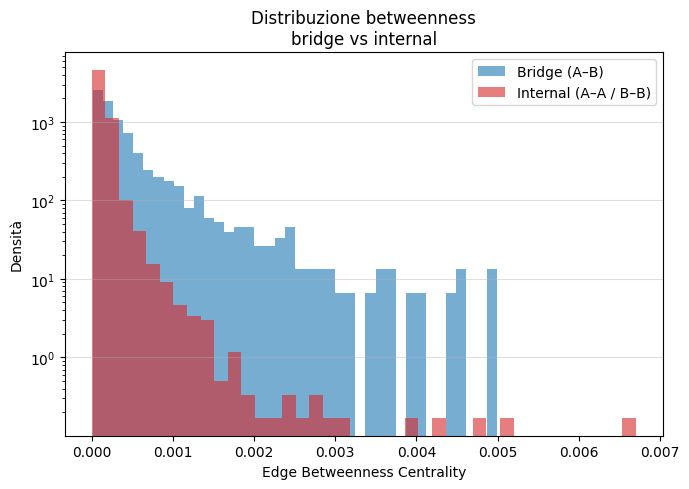

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))

color_bridge   = cmap(0)
color_internal = cmap(3)

for etype, color, label in [
    ('bridge',   color_bridge,   'Bridge (A–B)'),
    ('internal', color_internal, 'Internal (A–A / B–B)')
]:
    subset = df[df['edge_type'] == etype]['edge_betweenness']
    ax.hist(subset, bins=40, alpha=0.6, density=True, color=color, label=label)

ax.set_xlabel("Edge Betweenness Centrality")
ax.set_ylabel("Densità")
ax.set_yscale('log')
ax.set_title("Distribuzione betweenness\nbridge vs internal")
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

In [17]:
#Node betweenness in igraph 
bc_values_node = G.betweenness(directed=False, normalized=True)

bridge_nodes = set(df[df['edge_type'] == 'bridge']['node_u']) | \
               set(df[df['edge_type'] == 'bridge']['node_v'])

node_bc_rows = []
for v in G.vs:
    n = node_label(v.index)
    node_bc_rows.append({
        'node'          : n,
        'group'         : groups.get(v.index, '?'),
        'hierarchy'     : hierarchy.get(v.index, '?'),
        'node_bc'       : bc_values_node[v.index],
        'is_bridge_node': n in bridge_nodes,
    })

df_node_bc = pd.DataFrame(node_bc_rows)

result_bc = df_node_bc.groupby('is_bridge_node')['node_bc'].agg(
    count='count', mean='mean', std='std', max='max'
).round(6).rename(index={True: 'Bridge node', False: 'Non-bridge node'})

display(HTML("<b>Node betweenness: bridge nodes vs non-bridge nodes</b>"))
display(result_bc)

,count,mean,std,max
is_bridge_node,,,,
Non-bridge node,8422,0.000108,0.000735,0.050469
Bridge node,1097,0.002057,0.004787,0.064316


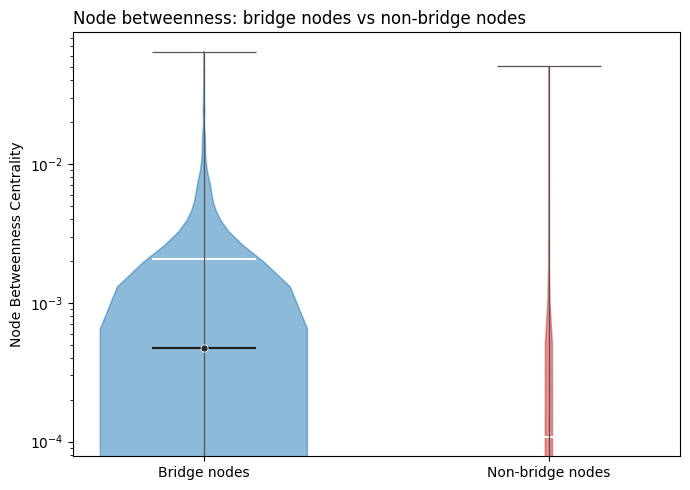

In [18]:
ROLE_ORDER  = [True, False]
ROLE_LABELS = ['Bridge nodes', 'Non-bridge nodes']
ROLE_COLORS = [cmap(0), cmap(3)]

data      = [df_node_bc[df_node_bc['is_bridge_node'] == r]['node_bc'].to_numpy()
             for r in ROLE_ORDER]
positions = [1, 2]
medians   = [np.median(d) for d in data]

fig, ax = plt.subplots(figsize=(7, 5))

vp = ax.violinplot(data, positions=positions, widths=0.6,
                   showmeans=True, showmedians=True, showextrema=True)

for body, color in zip(vp['bodies'], ROLE_COLORS):
    body.set_facecolor(color)
    body.set_edgecolor(color)
    body.set_linewidth(1.1)
    body.set_alpha(0.5)

vp['cmedians'].set_color('#222222')
vp['cmedians'].set_linewidth(1.6)
vp['cmeans'].set_color('#ffffff')
vp['cmeans'].set_linewidth(1.4)
for part in ['cbars', 'cmins', 'cmaxes']:
    vp[part].set_color('#555555')
    vp[part].set_linewidth(0.9)

ax.scatter(positions, medians, s=26, color="#282828",
           edgecolor='white', linewidth=0.55, zorder=4)

ax.set_xticks(positions)
ax.set_xticklabels(ROLE_LABELS)
ax.set_yscale('log')
ax.set_ylabel("Node Betweenness Centrality")
ax.set_title("Node betweenness: bridge nodes vs non-bridge nodes", loc='left')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Coreness

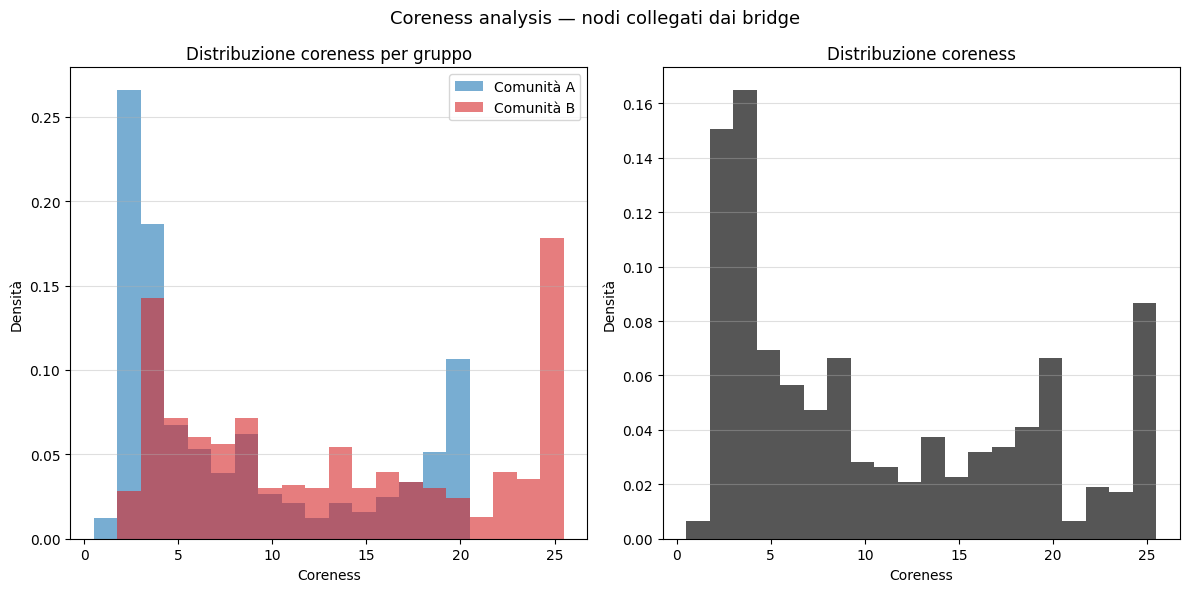

In [19]:
# Calcolo coreness
coreness_list = G.coreness()
degree_list   = G.degree()

core_number = {node_label(v.index): coreness_list[v.index] for v in G.vs}
degree      = {node_label(v.index): degree_list[v.index]   for v in G.vs}

bridge_nodes = set(df[df['edge_type'] == 'bridge']['node_u']) | \
               set(df[df['edge_type'] == 'bridge']['node_v'])

use_name = "name" in G.vertex_attributes()

core_rows = []
for n in bridge_nodes:
    v_idx = G.vs.find(name=n).index if use_name else int(n)
    core_rows.append({
        'node'     : n,
        'group'    : groups.get(v_idx, '?'),
        'hierarchy': hierarchy.get(v_idx, '?'),
        'degree'   : degree[n],
        'coreness' : core_number[n],
    })

df_core = pd.DataFrame(core_rows).sort_values('coreness', ascending=False)

#Plot
bins      = 20
x_min     = df_core['coreness'].min() - 0.5
x_max     = df_core['coreness'].max() + 0.5
bin_edges = np.linspace(x_min, x_max, bins + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for grp, color in [('A', cmap(0)), ('B', cmap(3))]:
    subset = df_core[df_core['group'] == grp]['coreness']
    if len(subset) == 0:
        continue
    counts, _ = np.histogram(subset, bins=bin_edges)
    density   = counts / counts.sum()
    axes[0].bar(bin_edges[:-1], density, width=np.diff(bin_edges),
                alpha=0.6, color=color, label=f'Comunità {grp}', align='edge')

axes[0].set_ylabel("Densità")
axes[0].set_title("Distribuzione coreness per gruppo")
axes[0].set_xlabel("Coreness")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)

counts_tot, _ = np.histogram(df_core['coreness'], bins=bin_edges)
density_tot   = counts_tot / counts_tot.sum()
axes[1].bar(bin_edges[:-1], density_tot, width=np.diff(bin_edges),
            alpha=0.7, color="#0E0E0E", align='edge')
axes[1].set_xlabel("Coreness")
axes[1].set_ylabel("Densità")
axes[1].set_title("Distribuzione coreness")
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle("Coreness analysis — nodi collegati dai bridge", fontsize=13)
plt.tight_layout()
plt.show()

# Normalizzazione 
Divido il numero di bridge che collegano nodo A con coreness K_A a nodo B con coreness K_B per il valore aspettato.
Il valore aspettato è calcolato come il prodotto tra i bridge totali e la probabilità che un bridge colleghi nodi con coreness K_A e K_B pesata per il grado. Questa probabilità è il prodotto delle probabilità che un nodo abbia coreness K_A o K_B pesata per il grado.
Si calcola quindi la somma di tutti i gradi dei nodi con coreness K_A e la si divide per la somma di tutti i gradi dei nodi della comunità A.

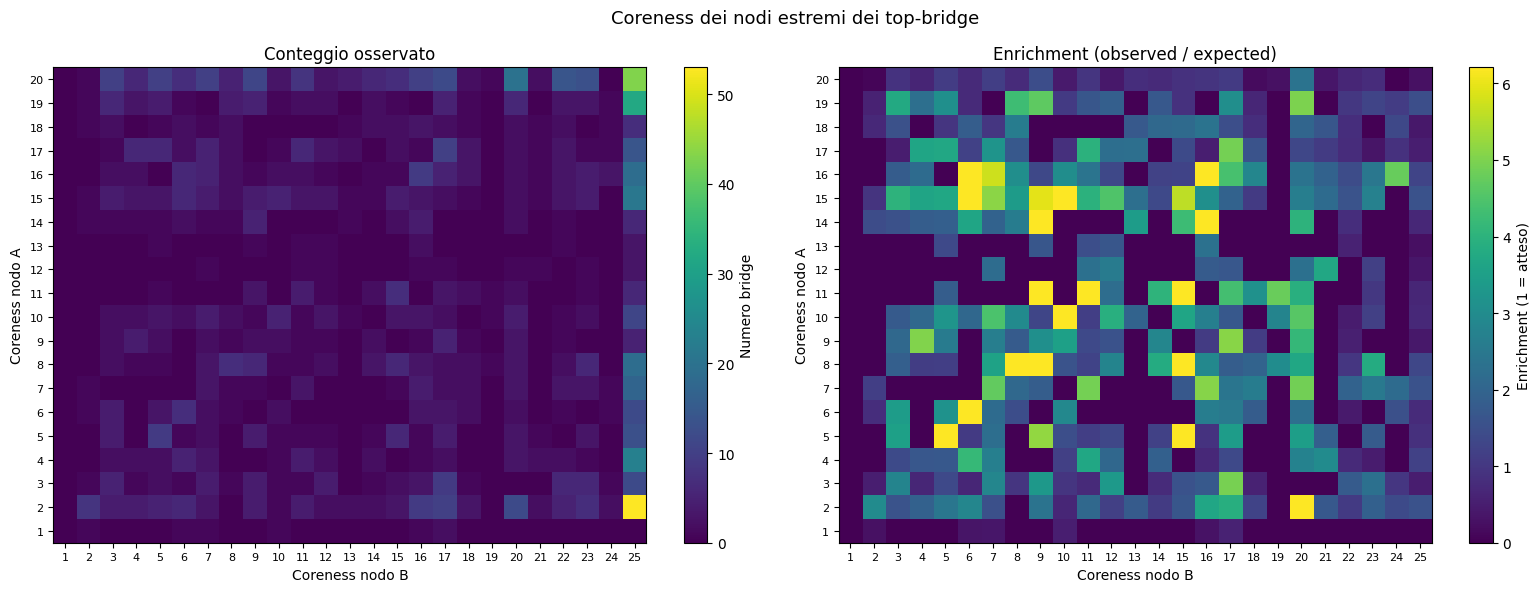

In [ ]:
from itertools import product as iproduct


# Crea dizionari per coreness e grado dei nodi
coreness_list = G.coreness()
degree_list   = G.degree()

core_number = {node_label(v.index): coreness_list[v.index] for v in G.vs}
degree      = {node_label(v.index): degree_list[v.index]   for v in G.vs}

# Costruisce df_scatter con direzione A→B 
use_name = "name" in G.vertex_attributes()

scatter_rows = []
for _, r in df[df['edge_type'] == 'bridge'].iterrows():
    u, v = r['node_u'], r['node_v']
    if r['group_u'] == 'A':
        node_A, node_B = u, v
    else:
        node_A, node_B = v, u
    scatter_rows.append({
        'coreness_A': core_number[node_A],
        'coreness_B': core_number[node_B],
    })



df_scatter    = pd.DataFrame(scatter_rows)
total_bridges = len(df_scatter)

# Crea stub pesati per grado (ovvero somma i gradi dei nodi per ogni livello di coreness) 
nodes_A = [node_label(v.index) for v in G.vs if groups.get(v.index) == 'A']
nodes_B = [node_label(v.index) for v in G.vs if groups.get(v.index) == 'B']

stub_A = {}
for n in nodes_A:
    k = core_number[n]
    stub_A[k] = stub_A.get(k, 0) + degree[n]

stub_B = {}
for n in nodes_B:
    k = core_number[n]
    stub_B[k] = stub_B.get(k, 0) + degree[n]

stub_A_tot = sum(stub_A.values())
stub_B_tot = sum(stub_B.values())



# Calcolo valori aspettti
expected_rows = []
for kA, kB in iproduct(stub_A.keys(), stub_B.keys()):
    prob     = (stub_A[kA] / stub_A_tot) * (stub_B[kB] / stub_B_tot)
    expected = prob * total_bridges
    expected_rows.append({'coreness_A': kA, 'coreness_B': kB, 'expected': expected})

df_exp = pd.DataFrame(expected_rows)

# Conteggio osservato 
df_obs = (df_scatter
          .groupby(['coreness_A', 'coreness_B'])
          .size()
          .reset_index(name='observed'))


df_enrich = df_obs.merge(df_exp, on=['coreness_A', 'coreness_B'], how='left') #mette insieme osservato e atteso per ogni coppia (kA, kB)
df_enrich['enrichment'] = df_enrich['observed'] / df_enrich['expected'] 



# --- Pivot per heatmap ---
all_kA = sorted(stub_A.keys())
all_kB = sorted(stub_B.keys())

#Crea matrice pivot per conteggio osservato e enrichment

pivot_obs = df_scatter.groupby(['coreness_A', 'coreness_B']).size().unstack(fill_value=0)
pivot_obs = pivot_obs.reindex(index=all_kA, columns=all_kB, fill_value=0)

pivot_enrich = df_enrich.pivot(index='coreness_A', columns='coreness_B', values='enrichment')
pivot_enrich = pivot_enrich.reindex(index=all_kA, columns=all_kB, fill_value=0).fillna(0)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im0 = axes[0].imshow(pivot_obs.values, aspect='auto', origin='lower', cmap='viridis')
axes[0].set_xticks(range(len(all_kB))); axes[0].set_xticklabels(all_kB, fontsize=8)
axes[0].set_yticks(range(len(all_kA))); axes[0].set_yticklabels(all_kA, fontsize=8)
axes[0].set_xlabel("Coreness nodo B"); axes[0].set_ylabel("Coreness nodo A")
axes[0].set_title("Conteggio osservato")
plt.colorbar(im0, ax=axes[0], label="Numero bridge")

vmax = df_enrich['enrichment'].quantile(0.95)
norm = plt.Normalize(vmin=0, vmax=vmax)

im1 = axes[1].imshow(pivot_enrich.values, aspect='auto', origin='lower',
                     cmap='viridis', norm=norm)
axes[1].set_xticks(range(len(all_kB))); axes[1].set_xticklabels(all_kB, fontsize=8)
axes[1].set_yticks(range(len(all_kA))); axes[1].set_yticklabels(all_kA, fontsize=8)
axes[1].set_xlabel("Coreness nodo B"); axes[1].set_ylabel("Coreness nodo A")
axes[1].set_title("Enrichment (observed / expected)")
plt.colorbar(im1, ax=axes[1], label="Enrichment (1 = atteso)")

plt.suptitle("Coreness dei nodi estremi dei top-bridge", fontsize=13)
plt.tight_layout()
plt.show()

# Coreness vs Betweennes nodi collegati dai top bridges

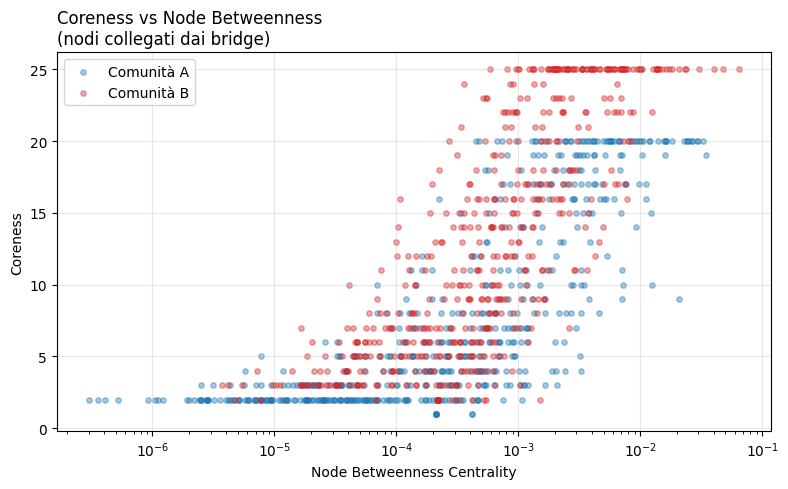

In [21]:
bridge_nodes = set(df[df['edge_type'] == 'bridge']['node_u']) | \
               set(df[df['edge_type'] == 'bridge']['node_v'])

scatter_rows = []
for v in G.vs:
    n = node_label(v.index)
    if n not in bridge_nodes:
        continue
    scatter_rows.append({
        'node'     : n,
        'group'    : groups.get(v.index, '?'),
        'coreness' : coreness_list[v.index],
        'node_bc'  : bc_values_node[v.index],
    })

df_cn = pd.DataFrame(scatter_rows)

fig, ax = plt.subplots(figsize=(8, 5))

for grp, color in [('A', cmap(0)), ('B', cmap(3))]:
    subset = df_cn[df_cn['group'] == grp]
    ax.scatter(subset['node_bc'], subset['coreness'],
               alpha=0.4, s=15, color=color, label=f'Comunità {grp}')

ax.set_xlabel("Node Betweenness Centrality")
ax.set_ylabel("Coreness")
ax.set_xscale('log')
ax.set_title("Coreness vs Node Betweenness\n(nodi collegati dai bridge)", loc='left')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

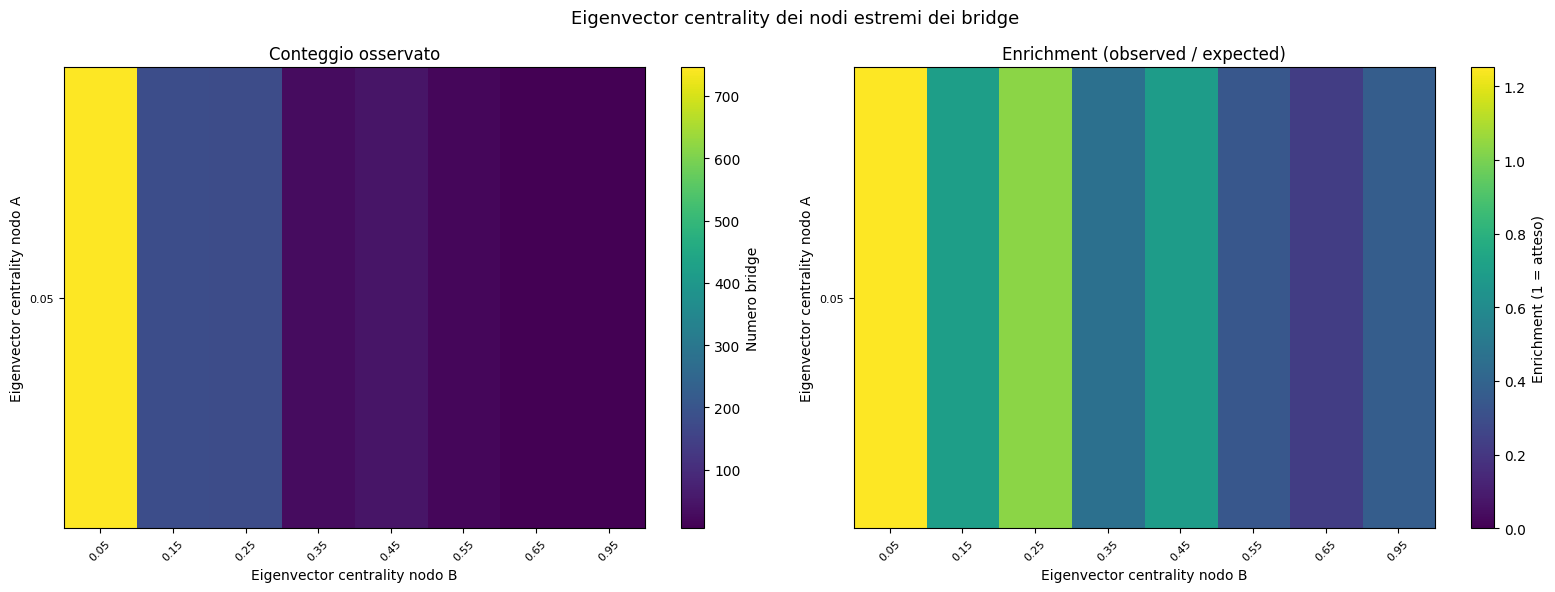

In [22]:
from itertools import product as iproduct

# --- Calcolo eigenvector centrality in igraph ---
use_name    = "name" in G.vertex_attributes()
degree_list = G.degree()

eig_values  = G.eigenvector_centrality(directed=True, scale=True)
eig_dict    = {node_label(v.index): eig_values[v.index] for v in G.vs}
degree      = {node_label(v.index): degree_list[v.index] for v in G.vs}

# --- Discretizza in N_BINS bin di uguale ampiezza ---
N_BINS   = 10
all_eigs = list(eig_dict.values())
bin_edges_eig = np.linspace(min(all_eigs), max(all_eigs), N_BINS + 1)
bin_labels    = [round((bin_edges_eig[i] + bin_edges_eig[i+1]) / 2, 3)
                 for i in range(N_BINS)]

def eig_bin(val):
    idx = np.searchsorted(bin_edges_eig[1:], val)
    return bin_labels[min(idx, N_BINS - 1)]

eig_bin_dict = {n: eig_bin(v) for n, v in eig_dict.items()}

# --- Costruisce df_scatter con direzione A→B ---
scatter_rows = []
for _, r in df[df['edge_type'] == 'bridge'].iterrows():
    u, v = r['node_u'], r['node_v']
    if r['group_u'] == 'A':
        node_A, node_B = u, v
    else:
        node_A, node_B = v, u
    scatter_rows.append({
        'eig_A': eig_bin_dict[node_A],
        'eig_B': eig_bin_dict[node_B],
    })

df_scatter    = pd.DataFrame(scatter_rows)
total_bridges = len(df_scatter)

# --- Configuration model: stub pesati per grado ---
nodes_A = [node_label(v.index) for v in G.vs if groups.get(v.index) == 'A']
nodes_B = [node_label(v.index) for v in G.vs if groups.get(v.index) == 'B']

stub_A = {}
for n in nodes_A:
    k = eig_bin_dict[n]
    stub_A[k] = stub_A.get(k, 0) + degree[n]

stub_B = {}
for n in nodes_B:
    k = eig_bin_dict[n]
    stub_B[k] = stub_B.get(k, 0) + degree[n]

stub_A_tot = sum(stub_A.values())
stub_B_tot = sum(stub_B.values())

# --- Expected per ogni coppia (eA, eB) ---
expected_rows = []
for eA, eB in iproduct(stub_A.keys(), stub_B.keys()):
    prob     = (stub_A[eA] / stub_A_tot) * (stub_B[eB] / stub_B_tot)
    expected = prob * total_bridges
    expected_rows.append({'eig_A': eA, 'eig_B': eB, 'expected': expected})

df_exp = pd.DataFrame(expected_rows)

# --- Conteggio osservato ---
df_obs = (df_scatter
          .groupby(['eig_A', 'eig_B'])
          .size()
          .reset_index(name='observed'))

# --- Merge e enrichment ---
df_enrich = df_obs.merge(df_exp, on=['eig_A', 'eig_B'], how='left')
df_enrich['enrichment'] = df_enrich['observed'] / df_enrich['expected']

# --- Pivot per heatmap ---
all_eA = sorted(stub_A.keys())
all_eB = sorted(stub_B.keys())

pivot_obs = df_scatter.groupby(['eig_A', 'eig_B']).size().unstack(fill_value=0)
pivot_obs = pivot_obs.reindex(index=all_eA, columns=all_eB, fill_value=0)

pivot_enrich = df_enrich.pivot(index='eig_A', columns='eig_B', values='enrichment')
pivot_enrich = pivot_enrich.reindex(index=all_eA, columns=all_eB, fill_value=0).fillna(0)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im0 = axes[0].imshow(pivot_obs.values, aspect='auto', origin='lower', cmap='viridis')
axes[0].set_xticks(range(len(all_eB))); axes[0].set_xticklabels(all_eB, fontsize=8, rotation=45)
axes[0].set_yticks(range(len(all_eA))); axes[0].set_yticklabels(all_eA, fontsize=8)
axes[0].set_xlabel("Eigenvector centrality nodo B")
axes[0].set_ylabel("Eigenvector centrality nodo A")
axes[0].set_title("Conteggio osservato")
plt.colorbar(im0, ax=axes[0], label="Numero bridge")

vmax = df_enrich['enrichment'].quantile(0.95)
norm = plt.Normalize(vmin=0, vmax=vmax)

im1 = axes[1].imshow(pivot_enrich.values, aspect='auto', origin='lower',
                     cmap='viridis', norm=norm)
axes[1].set_xticks(range(len(all_eB))); axes[1].set_xticklabels(all_eB, fontsize=8, rotation=45)
axes[1].set_yticks(range(len(all_eA))); axes[1].set_yticklabels(all_eA, fontsize=8)
axes[1].set_xlabel("Eigenvector centrality nodo B")
axes[1].set_ylabel("Eigenvector centrality nodo A")
axes[1].set_title("Enrichment (observed / expected)")
plt.colorbar(im1, ax=axes[1], label="Enrichment (1 = atteso)")

plt.suptitle("Eigenvector centrality dei nodi estremi dei bridge", fontsize=13)
plt.tight_layout()
plt.show()

Comunità A — min: 0.0000, max: 0.0677, mean: 0.0012
Comunità B — min: 0.0000, max: 1.0000, mean: 0.0285


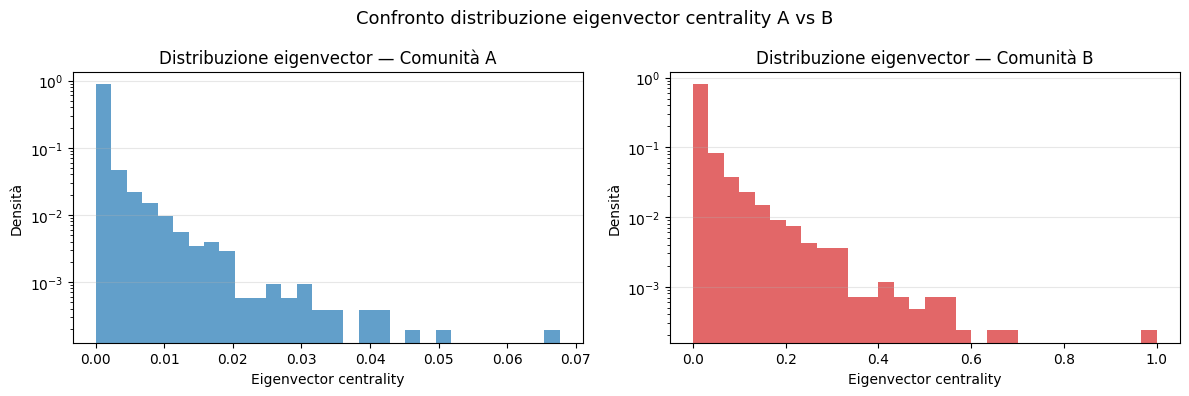

In [25]:
import matplotlib.pyplot as plt

eigs_A = [eig_dict[n] for n in nodes_A]
eigs_B = [eig_dict[n] for n in nodes_B]

print(f"Comunità A — min: {min(eigs_A):.4f}, max: {max(eigs_A):.4f}, mean: {np.mean(eigs_A):.4f}")
print(f"Comunità B — min: {min(eigs_B):.4f}, max: {max(eigs_B):.4f}, mean: {np.mean(eigs_B):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, eigs, label, color in [
    (axes[0], eigs_A, 'Comunità A', cmap(0)),
    (axes[1], eigs_B, 'Comunità B', cmap(3)),
]:
    counts, edges = np.histogram(eigs, bins=30)
    density = counts / counts.sum()
    ax.bar(edges[:-1], density, width=np.diff(edges), color=color, alpha=0.7, align='edge')
    ax.set_xlabel("Eigenvector centrality")
    ax.set_ylabel("Densità")
    ax.set_title(f"Distribuzione eigenvector — {label}")
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Confronto distribuzione eigenvector centrality A vs B", fontsize=13)
plt.tight_layout()
plt.show()

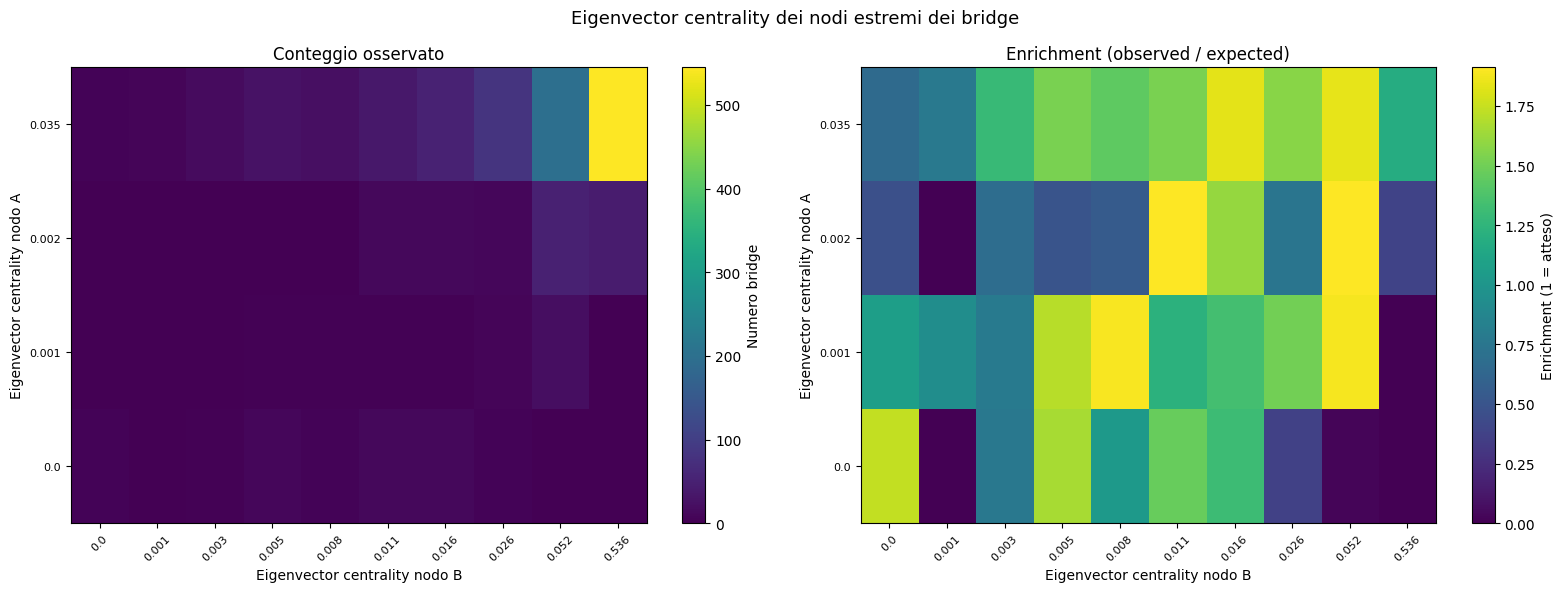

In [24]:
from itertools import product as iproduct

# --- Calcolo eigenvector centrality in igraph ---
use_name    = "name" in G.vertex_attributes()
degree_list = G.degree()

eig_values = G.eigenvector_centrality(directed=True, scale=True)
eig_dict   = {node_label(v.index): eig_values[v.index] for v in G.vs}
degree     = {node_label(v.index): degree_list[v.index] for v in G.vs}

nodes_A = [node_label(v.index) for v in G.vs if groups.get(v.index) == 'A']
nodes_B = [node_label(v.index) for v in G.vs if groups.get(v.index) == 'B']

# --- Bin basati sui quantili separati per A e B ---
N_BINS    = 10
quantiles = np.linspace(0, 1, N_BINS + 1)

all_eigs_A  = [eig_dict[n] for n in nodes_A]
all_eigs_B  = [eig_dict[n] for n in nodes_B]

bin_edges_A = np.unique(np.quantile(all_eigs_A, quantiles))
bin_edges_B = np.unique(np.quantile(all_eigs_B, quantiles))

bin_labels_A = [round((bin_edges_A[i] + bin_edges_A[i+1]) / 2, 3)
                for i in range(len(bin_edges_A) - 1)]
bin_labels_B = [round((bin_edges_B[i] + bin_edges_B[i+1]) / 2, 3)
                for i in range(len(bin_edges_B) - 1)]

def eig_bin_A(val):
    idx = np.searchsorted(bin_edges_A[1:], val)
    return bin_labels_A[min(idx, len(bin_labels_A) - 1)]

def eig_bin_B(val):
    idx = np.searchsorted(bin_edges_B[1:], val)
    return bin_labels_B[min(idx, len(bin_labels_B) - 1)]

eig_bin_dict_A = {n: eig_bin_A(eig_dict[n]) for n in nodes_A}
eig_bin_dict_B = {n: eig_bin_B(eig_dict[n]) for n in nodes_B}

# --- Costruisce df_scatter con direzione A→B ---
scatter_rows = []
for _, r in df[df['edge_type'] == 'bridge'].iterrows():
    u, v = r['node_u'], r['node_v']
    if r['group_u'] == 'A':
        node_A, node_B = u, v
    else:
        node_A, node_B = v, u
    scatter_rows.append({
        'eig_A': eig_bin_dict_A[node_A],
        'eig_B': eig_bin_dict_B[node_B],
    })

df_scatter    = pd.DataFrame(scatter_rows)
total_bridges = len(df_scatter)

# --- Configuration model: stub pesati per grado ---
stub_A = {}
for n in nodes_A:
    k = eig_bin_dict_A[n]
    stub_A[k] = stub_A.get(k, 0) + degree[n]

stub_B = {}
for n in nodes_B:
    k = eig_bin_dict_B[n]
    stub_B[k] = stub_B.get(k, 0) + degree[n]

stub_A_tot = sum(stub_A.values())
stub_B_tot = sum(stub_B.values())

# --- Expected per ogni coppia (eA, eB) ---
expected_rows = []
for eA, eB in iproduct(stub_A.keys(), stub_B.keys()):
    prob     = (stub_A[eA] / stub_A_tot) * (stub_B[eB] / stub_B_tot)
    expected = prob * total_bridges
    expected_rows.append({'eig_A': eA, 'eig_B': eB, 'expected': expected})

df_exp = pd.DataFrame(expected_rows)

# --- Conteggio osservato ---
df_obs = (df_scatter
          .groupby(['eig_A', 'eig_B'])
          .size()
          .reset_index(name='observed'))

# --- Merge e enrichment ---
df_enrich = df_obs.merge(df_exp, on=['eig_A', 'eig_B'], how='left')
df_enrich['enrichment'] = df_enrich['observed'] / df_enrich['expected']

# --- Pivot per heatmap ---
all_eA = sorted(stub_A.keys())
all_eB = sorted(stub_B.keys())

pivot_obs = df_scatter.groupby(['eig_A', 'eig_B']).size().unstack(fill_value=0)
pivot_obs = pivot_obs.reindex(index=all_eA, columns=all_eB, fill_value=0)

pivot_enrich = df_enrich.pivot(index='eig_A', columns='eig_B', values='enrichment')
pivot_enrich = pivot_enrich.reindex(index=all_eA, columns=all_eB, fill_value=0).fillna(0)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im0 = axes[0].imshow(pivot_obs.values, aspect='auto', origin='lower', cmap='viridis')
axes[0].set_xticks(range(len(all_eB))); axes[0].set_xticklabels(all_eB, fontsize=8, rotation=45)
axes[0].set_yticks(range(len(all_eA))); axes[0].set_yticklabels(all_eA, fontsize=8)
axes[0].set_xlabel("Eigenvector centrality nodo B")
axes[0].set_ylabel("Eigenvector centrality nodo A")
axes[0].set_title("Conteggio osservato")
plt.colorbar(im0, ax=axes[0], label="Numero bridge")

vmax = df_enrich['enrichment'].quantile(0.95)
norm = plt.Normalize(vmin=0, vmax=vmax)

im1 = axes[1].imshow(pivot_enrich.values, aspect='auto', origin='lower',
                     cmap='viridis', norm=norm)
axes[1].set_xticks(range(len(all_eB))); axes[1].set_xticklabels(all_eB, fontsize=8, rotation=45)
axes[1].set_yticks(range(len(all_eA))); axes[1].set_yticklabels(all_eA, fontsize=8)
axes[1].set_xlabel("Eigenvector centrality nodo B")
axes[1].set_ylabel("Eigenvector centrality nodo A")
axes[1].set_title("Enrichment (observed / expected)")
plt.colorbar(im1, ax=axes[1], label="Enrichment (1 = atteso)")

plt.suptitle("Eigenvector centrality dei nodi estremi dei bridge", fontsize=13)
plt.tight_layout()
plt.show()

# In più da valutare molto bene

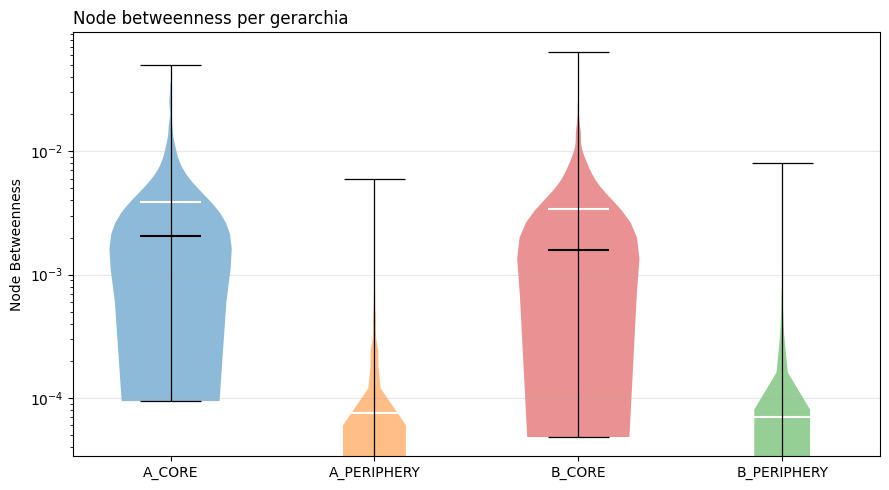

In [54]:
hier_order  = ['A_CORE', 'A_PERIPHERY', 'B_CORE', 'B_PERIPHERY']
hier_colors = [cmap(0), cmap(1), cmap(3), cmap(2)]

data      = [df_node_bc[df_node_bc['hierarchy'] == h]['node_bc'].to_numpy()
             for h in hier_order]
positions = list(range(1, len(hier_order) + 1))
medians   = [np.median(d) if len(d) > 0 else 0 for d in data]

fig, ax = plt.subplots(figsize=(9, 5))
vp = ax.violinplot([d for d in data if len(d) > 0],
                   positions=[p for p, d in zip(positions, data) if len(d) > 0],
                   widths=0.6,showmedians = True, showmeans=True, showextrema=True)

vp['cmeans'].set_color('#ffffff')
vp['cmedians'].set_color("#000000")

for body, color in zip(vp['bodies'], [c for c, d in zip(hier_colors, data) if len(d) > 0]):
    body.set_facecolor(color); body.set_alpha(0.5)

for part in ['cbars', 'cmins', 'cmaxes']:
    vp[part].set_color("#000000")
    vp[part].set_linewidth(0.9)

ax.set_xticks(positions)
ax.set_xticklabels(hier_order)
ax.set_yscale('log')
ax.set_ylabel("Node Betweenness")
ax.set_title("Node betweenness per gerarchia", loc='left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

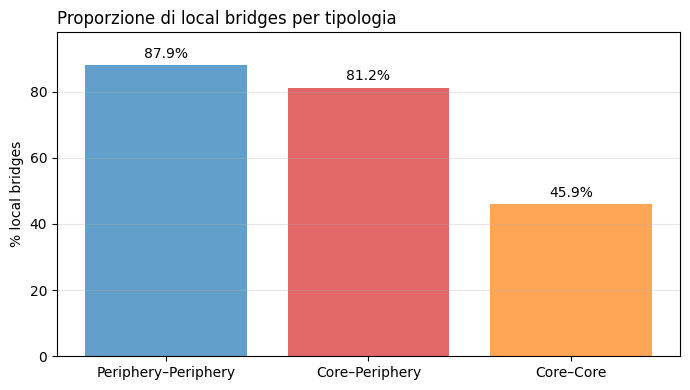

In [47]:
lb_pct = (bridges_df.groupby('bridge_role')['is_local_bridge']
          .mean() * 100).round(1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(lb_pct.index, lb_pct.values,
              color=[cmap(0), cmap(3), cmap(1)], alpha=0.7)
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_ylabel("% local bridges")
ax.set_title("Proporzione di local bridges per tipologia", loc='left')
ax.set_ylim(0, lb_pct.max() + 10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

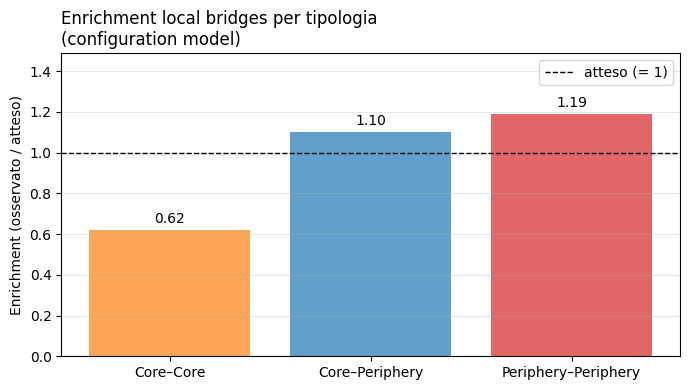

,total,local,obs_pct,exp_pct,enrichment
bridge_role,,,,,
Core–Core,292,134,0.4589,0.7389,0.6211
Core–Periphery,720,585,0.8125,0.7389,1.0996
Periphery–Periphery,206,181,0.8786,0.7389,1.1891


In [ ]:
# Local bridges per tipologia normalizzati

obs_lb = (bridges_df.groupby('bridge_role')['is_local_bridge']
          .agg(total='count', local='sum')
          .assign(obs_pct=lambda x: x['local'] / x['total']))



p_global = df[df['edge_type'] == 'bridge']['is_local_bridge'].mean()


stub_rows = []
for _, r in bridges_df.iterrows():
    u_idx = G.vs.find(name=r['node_u']).index if use_name else int(r['node_u'])
    v_idx = G.vs.find(name=r['node_v']).index if use_name else int(r['node_v'])
    w = (degree_list[u_idx] + degree_list[v_idx]) / 2
    stub_rows.append({
        'bridge_role'     : r['bridge_role'],
        'is_local_bridge' : r['is_local_bridge'],
        'weight'          : w,
    })

df_stub = pd.DataFrame(stub_rows)


expected_lb = (df_stub.groupby('bridge_role')
               .apply(lambda x: (x['weight'] * p_global).sum() / x['weight'].sum())
               .rename('exp_pct'))


result_lb = obs_lb.join(expected_lb)
result_lb['enrichment'] = result_lb['obs_pct'] / result_lb['exp_pct']

#Plot 
role_order = ['Core–Core', 'Core–Periphery', 'Periphery–Periphery']
colors     = [cmap(1), cmap(0), cmap(3)]

enrichments = [result_lb.loc[r, 'enrichment'] if r in result_lb.index else 0
               for r in role_order]

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(role_order, enrichments, color=colors, alpha=0.7)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1, label='atteso (= 1)')
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_ylabel("Enrichment (osservato / atteso)")
ax.set_title("Enrichment local bridges per tipologia\n(configuration model)", loc='left')
ax.set_ylim(0, max(enrichments) + 0.3)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


display(HTML("<b>Enrichment local bridges per tipologia</b>"))
display(result_lb[['total', 'local', 'obs_pct', 'exp_pct', 'enrichment']].round(4))